# Logistic Regression Classifier -- Urdu News Article Classifier
**Project:** Multi-class classification of Urdu news into 5 categories  
**Dataset:** 1140 articles | Sources: Express, Geo, Jang  
**Categories:** Business, Entertainment, Science and Technology, Sports, World  

Custom Bag-of-Words, Elastic Net regularisation, batch gradient descent, one-vs-all strategy.

## 1. Imports and Configuration

In [3]:
# !pip3 install tensorflow --break-system-packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
# import tensorflow

# !pip3 install urduhack --break-system-packages
from urduhack import stop_words
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# -- Constants --
DATA_PATH = "../data/combined_file.csv"
TEST_SIZE = 0.2
RANDOM_STATE = 42
EPOCHS = 180
LEARNING_RATE = 0.1
ELASTIC_NET_ALPHA = 0.0001   # regularisation strength
L1_RATIO = 0.1               # Elastic Net mixing (1=full L1, 0=full L2)

CATEGORIES = ['sports', 'world', 'entertainment', 'science-technology', 'business']

## 2. Data Loading and EDA

In [4]:
articles = pd.read_csv(DATA_PATH)
articles['content'] = articles['content'].astype(str)
articles['title'] = articles['title'].astype(str)

print(f"Dataset shape: {articles.shape}")
print(f"\nMissing values:\n{articles.isnull().sum()}")
print(f"\nCategory distribution:\n{articles['gold_label'].value_counts()}")
articles.head()

Dataset shape: (1193, 5)

Missing values:
id            0
title         0
link          0
content       0
gold_label    0
dtype: int64

Category distribution:
gold_label
science-technology    240
world                 240
entertainment         239
sports                238
business              236
Name: count, dtype: int64


,id,title,link,content,gold_label
0,0,سلمان کے بعد شاہ رخ خان کو بھی جان سے مارنےکی ...,https://urdu.geo.tv/latest/385991-,ممبئی: بالی وڈ اداکار سلمان خان کے بعد اب کنگ...,entertainment
1,1,طلاق کی خبروں کے باوجود ابھیشیک اور ایشوریا کو...,https://urdu.geo.tv/latest/385972-,بالی وڈ کی معروف جوڑی ایشوریا رائے اور ابھیشیک...,entertainment
2,2,'میرا اپنا دماغ خراب تھا'، نادیہ خان نے کم عمر...,https://urdu.geo.tv/latest/385943-,پاکستان شوبز انڈسٹری کی معروف میزبان و اداکارہ...,entertainment
3,3,امیتابھ نہ شاہ رخ، بالی وڈ میں سب سے پہلے رولز...,https://urdu.geo.tv/latest/385850-,رولز رائس کا شمار لگژری اور مہنگی ترین گاڑیوں ...,entertainment
4,4,ہنی سنگھ کی پاکستانی گلوکار کو کریڈٹ دیکر سرا...,https://urdu.geo.tv/latest/385820-,بالی وڈ میں پاکستانی گانوں کو ہمیشہ ہی پسند کی...,entertainment


Content length stats:
count    1193.000000
mean     1047.906119
std       648.458299
min         3.000000
25%       668.000000
50%       924.000000
75%      1246.000000
max      6395.000000
Name: content_length, dtype: float64


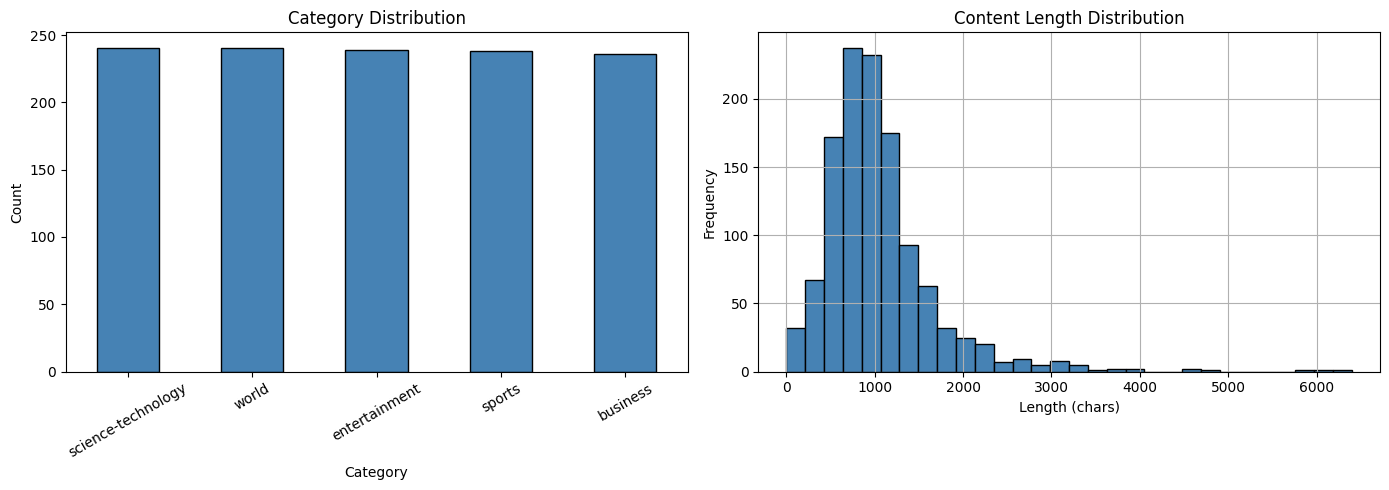

In [6]:
# -- Content Length Analysis --
articles['content_length'] = articles['content'].apply(len)

print(f"Content length stats:\n{articles['content_length'].describe()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

articles['gold_label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

articles['content_length'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Content Length Distribution')
axes[1].set_xlabel('Length (chars)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
# plt.savefig('distribution.png', dpi=150)
plt.show()

## 3. Preprocessing

In [7]:
URL_PATTERN = r'https?://\S+|www\.\S+|\d+|\'|\'| ؔ\'|\,'
URDU_PUNCT_PATTERN = r'[،۔؛؟\u060C\u061F\u061B\u06D4\u06D5\u066B\u066F\u200C]+'

def clean_text(text: str) -> str:
    """Remove URLs, Urdu punctuation, digits, and stopwords."""
    sw = stop_words.STOP_WORDS
    text = re.sub(URL_PATTERN, ' ', str(text))
    text = re.sub(URDU_PUNCT_PATTERN, ' ', text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    tokens = [w for w in text.split() if w not in sw]
    return " ".join(tokens)

articles['cleaned_content'] = articles['content'].apply(clean_text)

print(articles[['content', 'cleaned_content']].head())

                                             content  \
0  ممبئی: بالی وڈ اداکار سلمان خان کے بعد  اب کنگ...   
1  بالی وڈ کی معروف جوڑی ایشوریا رائے اور ابھیشیک...   
2  پاکستان شوبز انڈسٹری کی معروف میزبان و اداکارہ...   
3  رولز رائس کا شمار لگژری اور مہنگی ترین گاڑیوں ...   
4  بالی وڈ میں پاکستانی گانوں کو ہمیشہ ہی پسند کی...   

                                     cleaned_content  
0  ممبئی بالی وڈ اداکار سلمان خان کنگ خان کہلائے ...  
1  بالی وڈ معروف جوڑی ایشوریا رائے ابھیشیک بچن طل...  
2  پاکستان شوبز انڈسٹری معروف میزبان اداکارہ نادی...  
3  رولز رائس شمار لگژری مہنگی ترین گاڑیوں بالی وڈ...  
4  بالی وڈ پاکستانی گانوں ہمیشہ پسند چرایا پاکستا...  


## 4. Train / Test Split

In [9]:
data = articles['cleaned_content']
labels = articles['gold_label']

train_x, test_x, train_y, test_y = train_test_split(
    data, labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
print(f"Train size: {len(train_x)}  |  Test size: {len(test_x)}")

Train size: 954  |  Test size: 239


## 5. Custom Bag-of-Words Vectoriser

In [10]:
class BagOfWords:
    """Simple Bag-of-Words vectoriser built from scratch."""

    def __init__(self):
        self.vocab: list = []
        self._word_to_idx: dict = {}

    def fit(self, corpus: pd.Series) -> None:
        """Build vocabulary from training corpus."""
        all_words: set = set()
        for text in corpus:
            all_words.update(text.split())
        self.vocab = list(all_words)
        self._word_to_idx = {w: i for i, w in enumerate(self.vocab)}

    def vectorise(self, text: str) -> list:
        """Convert a single document to a count vector; OOV words are ignored."""
        tokens = text.split()
        vector = [0] * len(self.vocab)
        for token in tokens:
            idx = self._word_to_idx.get(token)
            if idx is not None:
                vector[idx] += 1
        return vector


bow = BagOfWords()
bow.fit(train_x)
print(f"Vocabulary size: {len(bow.vocab)}")

train_x_vector = np.array([bow.vectorise(doc) for doc in train_x])
test_x_vector = np.array([bow.vectorise(doc) for doc in test_x])

print(f"Train matrix: {train_x_vector.shape}  |  Test matrix: {test_x_vector.shape}")

Vocabulary size: 10644
Train matrix: (954, 10644)  |  Test matrix: (239, 10644)


## 6. Logistic Regression -- From Scratch

Batch gradient descent with **Elastic Net regularisation** and a **one-vs-all** strategy.

In [11]:
class LogisticRegression:
    """Binary logistic regression with Elastic Net regularisation."""

    def __init__(self, learning_rate: float, n_features: int):
        self.weights = np.zeros((n_features, 1))
        self.bias = 0.0
        self.lr = learning_rate

    # -- helpers --
    def _sigmoid(self, z: np.ndarray) -> np.ndarray:
        return 1.0 / (1.0 + np.exp(-z))

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Return P(y=1 | X)."""
        return self._sigmoid(X @ self.weights + self.bias)

    def cross_entropy_loss(self, X: np.ndarray, y: np.ndarray) -> float:
        p = self.predict(X)
        return float(
            -np.mean(y * np.log(p + 1e-9) + (1 - y) * np.log(1 - p + 1e-9))
        )

    def evaluate(self, X: np.ndarray, y: np.ndarray) -> float:
        return accuracy_score(y, np.round(self.predict(X)))

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
        epochs: int = EPOCHS,
        alpha: float = ELASTIC_NET_ALPHA,
        l1_ratio: float = L1_RATIO,
    ):
        """Batch gradient descent with Elastic Net."""
        n = len(y_train)
        train_losses, val_losses = [], []

        for _ in range(epochs):
            p = self.predict(X_train)
            grad = X_train.T @ (p - y_train) / n

            # Elastic Net update: L1 term via sign, L2 term via weight magnitude
            self.weights -= self.lr * (
                grad
                + (1 - l1_ratio) * alpha * self.weights
                + l1_ratio * alpha * np.sign(self.weights)
            )
            self.bias -= self.lr * float(np.mean(p - y_train))

            train_losses.append(self.cross_entropy_loss(X_train, y_train))
            val_losses.append(self.cross_entropy_loss(X_val, y_val))

        return train_losses, val_losses

In [12]:
# One-vs-All: one binary classifier per category
classifiers = {}
losses = {}

for cat in CATEGORIES:
    y_bin_train = np.array(train_y == cat, dtype=float).reshape(-1, 1)
    y_bin_test = np.array(test_y == cat, dtype=float).reshape(-1, 1)

    clf = LogisticRegression(LEARNING_RATE, train_x_vector.shape[1])
    train_loss, val_loss = clf.fit(
        train_x_vector, y_bin_train,
        test_x_vector, y_bin_test,
    )
    classifiers[cat] = clf
    losses[cat] = (train_loss, val_loss)
    print(f"Trained classifier for: {cat}  (epochs={EPOCHS})")

Trained classifier for: sports  (epochs=180)
Trained classifier for: world  (epochs=180)
Trained classifier for: entertainment  (epochs=180)
Trained classifier for: science-technology  (epochs=180)
Trained classifier for: business  (epochs=180)


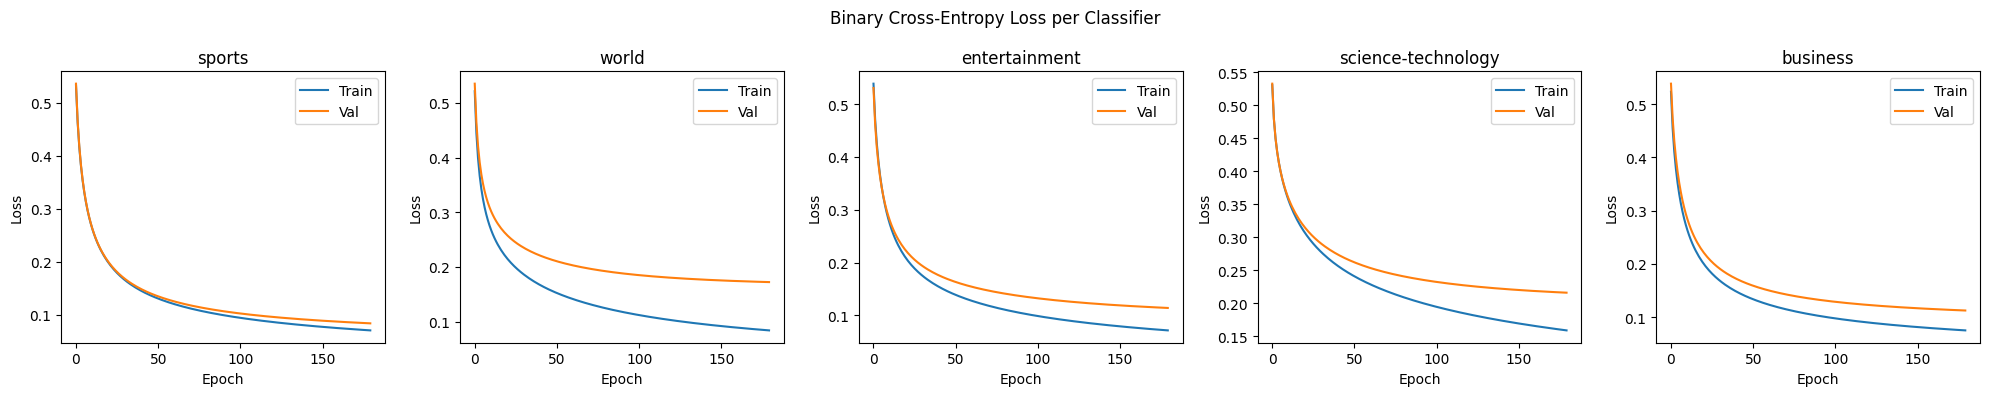

In [13]:
# -- Plot loss curves --
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(20, 4))
for ax, cat in zip(axes, CATEGORIES):
    train_loss, val_loss = losses[cat]
    ax.plot(train_loss, label='Train')
    ax.plot(val_loss, label='Val')
    ax.set_title(cat)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.suptitle('Binary Cross-Entropy Loss per Classifier')
plt.tight_layout()
plt.savefig('lr_loss_curves.png', dpi=150)
plt.show()

## 7. Evaluation

In [14]:
# Collect logits from all classifiers and take hard-max
logits = np.column_stack([
    classifiers[cat].predict(test_x_vector) for cat in CATEGORIES
])
pred_indices = np.argmax(logits, axis=1)
pred_labels = pd.Series(pred_indices).map({i: c for i, c in enumerate(CATEGORIES)})

print(f"Accuracy: {accuracy_score(test_y, pred_labels):.4f}")
print("\nClassification Report:")
print(classification_report(test_y, pred_labels))

Accuracy: 0.9331

Classification Report:
                    precision    recall  f1-score   support

          business       0.94      0.94      0.94        48
     entertainment       0.98      0.98      0.98        46
science-technology       0.91      0.85      0.88        46
            sports       1.00      0.98      0.99        48
             world       0.85      0.92      0.89        51

          accuracy                           0.93       239
         macro avg       0.94      0.93      0.93       239
      weighted avg       0.93      0.93      0.93       239



## 8. Confusion Matrix

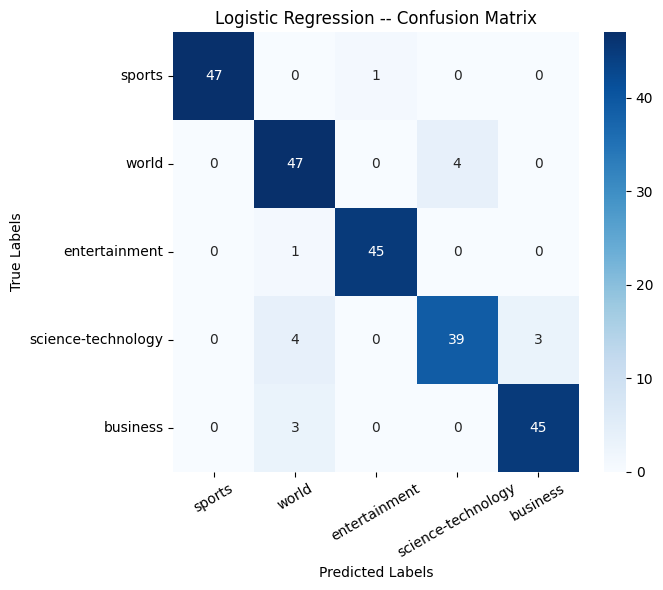

In [15]:
cm = confusion_matrix(test_y, pred_labels, labels=CATEGORIES)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CATEGORIES, yticklabels=CATEGORIES,
)
plt.title('Logistic Regression -- Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()